# Data Preprocessing

## Objective

The objective of this notebook is to transform the raw dataset into a machine learning-ready dataset by removing unnecessary features, handling missing values, encoding categorical variables, scaling numerical features, and preparing the data for model training.

In [37]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Train/Test Split
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [38]:
#Load Dataset

df = pd.read_csv("../data/raw/Support_tickets.csv")
df.head()

,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,org_users,region,region_cat,past_30d_tickets,past_90d_incidents,product_area,product_area_cat,booking_channel,booking_channel_cat,reported_by_role,reported_by_role_cat,customers_affected,error_rate_pct,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,126,APAC,3,2,0,mobile,3,web,1,support,1,2,5.45,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,101,AMER,1,2,3,analytics,5,chat,3,product_manager,3,24,2.50,2,0,0,0,0,neutral,2,461,low,1
2,1000000002,Mon,1,100012,Small,1,gaming,4,Basic,1,71,APAC,3,3,1,notifications,6,chat,3,devops,2,1,3.33,0,0,0,0,1,positive,3,306,low,1
3,1000000003,Wed,3,100003,Small,1,media,7,Plus,2,100,AMER,1,2,2,analytics,5,chat,3,finance,4,25,2.93,16,0,0,0,1,neutral,2,363,medium,2
4,1000000004,Mon,1,100019,Small,1,ecommerce,2,Plus,2,332,AMER,1,5,1,analytics,5,web,1,support,1,28,3.26,6,0,0,0,0,neutral,2,442,low,1


In [39]:
# Target variable
target_column = "priority"

# Identifier columns
identifier_columns = [
    "ticket_id",
    "company_id"
]

In [40]:
#Dataset Overview

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 50,000
Columns: 33


## Remove Non-Predictive and Redundant Features

Based on the exploratory data analysis, identifier columns and pre-encoded categorical variables will be removed to ensure a clean, reproducible preprocessing pipeline.

In [41]:
#Removal of the variables

columns_to_drop = [

    # Identifiers
    "ticket_id",
    "company_id",

    # Pre-encoded categorical variables
    "booking_channel_cat",
    "company_size_cat",
    "customer_tier_cat",
    "industry_cat",
    "product_area_cat",
    "region_cat",
    "reported_by_role_cat",
    "priority_cat",
    "customer_sentiment_cat",

    # Redundant feature
    "day_of_week_num"

]

df = df.drop(columns=columns_to_drop)

print(f"Remaining columns: {df.shape[1]}")


Remaining columns: 21


In [42]:
#Verification of the Dataset

df.head()

,day_of_week,company_size,industry,customer_tier,org_users,region,past_30d_tickets,past_90d_incidents,product_area,booking_channel,reported_by_role,customers_affected,error_rate_pct,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,description_length,priority
0,Wed,Small,media,Basic,126,APAC,2,0,mobile,web,support,2,5.45,6,0,0,0,0,neutral,227,low
1,Sat,Small,healthcare,Basic,101,AMER,2,3,analytics,chat,product_manager,24,2.50,2,0,0,0,0,neutral,461,low
2,Mon,Small,gaming,Basic,71,APAC,3,1,notifications,chat,devops,1,3.33,0,0,0,0,1,positive,306,low
3,Wed,Small,media,Plus,100,AMER,2,2,analytics,chat,finance,25,2.93,16,0,0,0,1,neutral,363,medium
4,Mon,Small,ecommerce,Plus,332,AMER,5,1,analytics,web,support,28,3.26,6,0,0,0,0,neutral,442,low


In [43]:
#Missing Values
missing_summary = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": (
        df.isnull().mean() * 100
    ).round(2)

})

missing_summary.query("`Missing Values` > 0")

,Missing Values,Percentage
customer_sentiment,906,1.81


## Missing Value Analysis

Before selecting an imputation strategy, it is important to determine whether the missing values occur randomly or follow a systematic pattern. Understanding the distribution of missing values helps ensure that preprocessing decisions are based on evidence rather than assumptions.

In [44]:
#Variable Creation only for analysis
df["missing_customer_sentiment"] = (
    df["customer_sentiment"]
    .isna()
)

In [45]:
#General Distribution
missing_distribution = (
    df["missing_customer_sentiment"]
      .value_counts()
      .rename_axis("Missing")
      .reset_index(name="Count")
)

missing_distribution["Percentage"] = (
    missing_distribution["Count"] /
    len(df) * 100
).round(2)

missing_distribution

,Missing,Count,Percentage
0,False,49094,98.19
1,True,906,1.81


In [46]:
#Do NaN appear more frequently in certain priorities? 
pd.crosstab(
    df[target_column],
    df["missing_customer_sentiment"],
    normalize="index"
).round(3)

missing_customer_sentiment,False,True
priority,,
high,0.97,0.03
low,0.99,0.01
medium,0.98,0.02


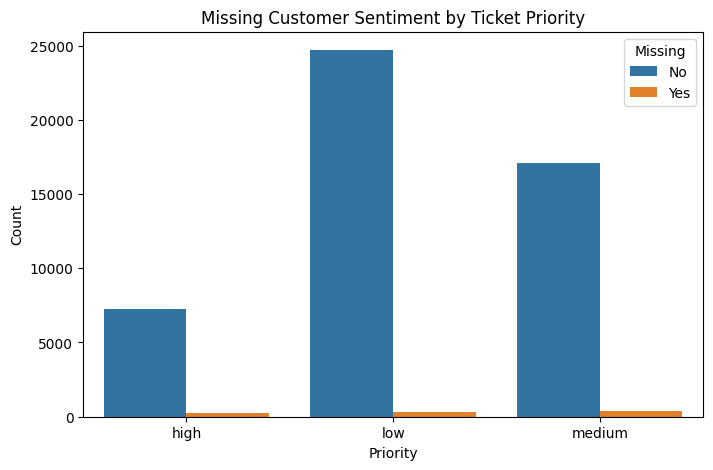

In [47]:
#Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x=target_column,
    hue="missing_customer_sentiment",
    order=sorted(df[target_column].unique())
)

plt.title("Missing Customer Sentiment by Ticket Priority")

plt.xlabel("Priority")

plt.ylabel("Count")

plt.legend(
    title="Missing",
    labels=["No", "Yes"]
)

plt.show()

In [48]:
#Enterprise Size

pd.crosstab(
    df["company_size"],
    df["missing_customer_sentiment"],
    normalize="index"
).round(3)

missing_customer_sentiment,False,True
company_size,,
Large,0.96,0.04
Medium,0.98,0.02
Small,0.99,0.01


In [49]:
# Region

pd.crosstab(
    df["region"],
    df["missing_customer_sentiment"],
    normalize="index"
).round(3)

missing_customer_sentiment,False,True
region,,
AMER,0.97,0.03
APAC,0.99,0.01
EMEA,0.98,0.02


In [50]:
#Industry

pd.crosstab(
    df["industry"],
    df["missing_customer_sentiment"],
    normalize="index"
).round(3)

missing_customer_sentiment,False,True
industry,,
ecommerce,0.99,0.01
fintech,0.98,0.02
gaming,0.99,0.01
healthcare,0.98,0.02
logistics,0.97,0.03
media,0.98,0.02
saas_b2b,0.98,0.02


In [51]:
#Booking Channel

pd.crosstab(
    df["booking_channel"],
    df["missing_customer_sentiment"],
    normalize="index"
).round(3)


missing_customer_sentiment,False,True
booking_channel,,
chat,1.00,0.00
email,1.00,0.00
phone,0.85,0.15
web,1.00,0.00


### Interpretation

Evaluate whether the proportion of missing values remains relatively consistent across ticket priorities and customer segments.

If no meaningful differences are observed, the missing values can be considered approximately random, making standard imputation strategies appropriate.

If specific groups exhibit noticeably higher missing rates, the missing values may contain useful information and should be handled more carefully during preprocessing.

### Missing Value Strategy

The missing values in `customer_sentiment` do not appear to be completely random. Most missing observations are associated with tickets submitted through the phone channel, suggesting that customer sentiment may not have been consistently recorded during phone interactions.

Rather than imputing the most frequent category or removing observations, the missing values will be replaced with a new category (`Unknown`). This approach preserves all observations while retaining potentially useful information about the absence of customer sentiment.

In [52]:
df["customer_sentiment"] = (
    df["customer_sentiment"]
    .fillna("Unknown")
)

In [53]:
missing_after = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing_after.query("`Missing Values` > 0")

,Missing Values,Percentage


### Summary

The missing values in `customer_sentiment` were successfully addressed by introducing a new category (`Unknown`).

This approach preserves all observations while explicitly representing cases where customer sentiment was not recorded, avoiding the introduction of bias that could result from imputing the most frequent category.

As a result, the dataset contains no remaining missing values and is ready for the next preprocessing steps.

# 6. Feature Encoding

Machine learning algorithms require numerical input features. Therefore, categorical variables must be transformed into numerical representations while preserving their underlying meaning.

Different encoding techniques are applied depending on whether a feature represents nominal or ordinal categories.

In [54]:
#Variable Classification

encoding_strategy = pd.DataFrame({

    "Feature": [

        "company_size",
        "customer_tier",
        "industry",
        "region",
        "booking_channel",
        "reported_by_role",
        "product_area",
        "day_of_week",
        "customer_sentiment"

    ],

    "Variable Type": [

        "Ordinal",
        "Ordinal",
        "Nominal",
        "Nominal",
        "Nominal",
        "Nominal",
        "Nominal",
        "Nominal",
        "Nominal"

    ],

    "Encoding Method": [

        "Ordinal Encoding",
        "Ordinal Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding",
        "One-Hot Encoding"

    ],

    "Reason": [

        "Natural order (Small < Medium < Large)",
        "Natural hierarchy (Basic < Plus < Enterprise)",
        "No inherent order",
        "No inherent order",
        "No inherent order",
        "No inherent order",
        "No inherent order",
        "Days are treated as categorical values",
        "Includes the 'Unknown' category"

    ]

})

encoding_strategy

,Feature,Variable Type,Encoding Method,Reason
0,company_size,Ordinal,Ordinal Encoding,Natural order (Small < Medium < Large)
1,customer_tier,Ordinal,Ordinal Encoding,Natural hierarchy (Basic < Plus < Enterprise)
2,industry,Nominal,One-Hot Encoding,No inherent order
3,region,Nominal,One-Hot Encoding,No inherent order
4,booking_channel,Nominal,One-Hot Encoding,No inherent order
5,reported_by_role,Nominal,One-Hot Encoding,No inherent order
6,product_area,Nominal,One-Hot Encoding,No inherent order
7,day_of_week,Nominal,One-Hot Encoding,Days are treated as categorical values
8,customer_sentiment,Nominal,One-Hot Encoding,Includes the 'Unknown' category


In [55]:
#Column Definition

ordinal_features = [
    "company_size",
    "customer_tier"
]

nominal_features = [
    "industry",
    "region",
    "booking_channel",
    "reported_by_role",
    "product_area",
    "day_of_week",
    "customer_sentiment"
]

In [56]:
#Ordinal Encoding

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(

    categories=[
        ["Small", "Medium", "Large"],
        ["Basic", "Plus", "Enterprise"]
    ]
)

df[ordinal_features] = ordinal_encoder.fit_transform(
    df[ordinal_features]
)

In [57]:
#Verification of Ordinal Encoding

df[ordinal_features].head(15)

,company_size,customer_tier
0,0.00,0.00
1,0.00,0.00
2,0.00,0.00
3,0.00,1.00
4,0.00,1.00
5,1.00,2.00
6,0.00,0.00
7,0.00,0.00
8,2.00,2.00
9,1.00,1.00


### Why OrdinalEncoder instead of LabelEncoder?

`OrdinalEncoder` allows explicit control over the ordering of categories, ensuring that the encoded values accurately represent the natural hierarchy of the variables.

`LabelEncoder` assigns values alphabetically and is intended primarily for encoding target variables rather than input features.

### One-Hot Encoding

Nominal categorical variables have no intrinsic ordering. Therefore, One-Hot Encoding is applied to convert each category into a binary feature while avoiding the introduction of artificial ordinal relationships.

The encoder is configured with `handle_unknown="ignore"` to ensure robustness when unseen categories appear in future datasets.

In [58]:
#Encoder Creation
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(

    handle_unknown="ignore",
    sparse_output=False

)

In [59]:
#Application

encoded_features = onehot_encoder.fit_transform(
    df[nominal_features]
)

In [60]:
encoded_columns = onehot_encoder.get_feature_names_out(
    nominal_features
)

In [61]:
#Convert to DataFrame

encoded_df = pd.DataFrame(

    encoded_features,

    columns=encoded_columns,

    index=df.index

)

In [62]:
#Merge the encoded features with the original DataFrame
df = pd.concat(

    [

        df.drop(columns=nominal_features),

        encoded_df

    ],

    axis=1

)

In [63]:
#Verification

df.head()

,company_size,customer_tier,org_users,past_30d_tickets,past_90d_incidents,customers_affected,error_rate_pct,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,description_length,priority,missing_customer_sentiment,industry_ecommerce,industry_fintech,industry_gaming,industry_healthcare,industry_logistics,industry_media,industry_saas_b2b,region_AMER,region_APAC,region_EMEA,booking_channel_chat,booking_channel_email,booking_channel_phone,booking_channel_web,reported_by_role_c_level,reported_by_role_devops,reported_by_role_finance,reported_by_role_product_manager,reported_by_role_support,product_area_analytics,product_area_auth,product_area_billing,product_area_data_pipeline,product_area_mobile,product_area_notifications,day_of_week_Fri,day_of_week_Mon,day_of_week_Sat,day_of_week_Sun,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed,customer_sentiment_Unknown,customer_sentiment_negative,customer_sentiment_neutral,customer_sentiment_positive
0,0.00,0.00,126,2,0,2,5.45,6,0,0,0,0,227,low,False,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
1,0.00,0.00,101,2,3,24,2.50,2,0,0,0,0,461,low,False,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
2,0.00,0.00,71,3,1,1,3.33,0,0,0,0,1,306,low,False,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
3,0.00,1.00,100,2,2,25,2.93,16,0,0,0,1,363,medium,False,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
4,0.00,1.00,332,5,1,28,3.26,6,0,0,0,0,442,low,False,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00


In [64]:
#Data Type

df.dtypes.value_counts()

float64    39
int64      10
str         1
bool        1
Name: count, dtype: int64

In [65]:
df.drop(columns=["missing_customer_sentiment"], inplace=True)

### Column was dropped as it is perceived as a temporal column

In [66]:
df.select_dtypes(include=["object", "string", "bool"]).columns

Index(['priority'], dtype='str')

# 6. Prepare Features and Target

Before training machine learning models, the dataset is divided into:

- **Features (X):** Predictor variables used for training.
- **Target (y):** The variable to be predicted (`priority`).

In [67]:
#Creation of the target variable
priority_mapping = {
    "low": 0,
    "medium": 1,
    "high": 2
}

df["priority"] = df["priority"].map(priority_mapping)

In [68]:
original_df = pd.read_csv("../data/raw/Support_tickets.csv")

df["priority"] = original_df["priority"]

In [69]:
df["priority"].head()

0       low
1       low
2       low
3    medium
4       low
Name: priority, dtype: str

In [70]:
priority_mapping = {
    "low": 0,
    "medium": 1,
    "high": 2
}

df["priority"] = (
    df["priority"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(priority_mapping)
)

In [71]:
print(df["priority"].head())

print("\n")

print(df["priority"].value_counts(dropna=False))

print("\n")

print("Missing values:", df["priority"].isna().sum())

0    0
1    0
2    0
3    1
4    0
Name: priority, dtype: int64


priority
0    25000
1    17500
2     7500
Name: count, dtype: int64


Missing values: 0


In [72]:
df["priority"].value_counts(dropna=False)

priority
0    25000
1    17500
2     7500
Name: count, dtype: int64

In [73]:
# Creation of X & Y

X = df.drop(columns=["priority"])
y = df["priority"]

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 7. Feature Scaling

Continuous numerical features are standardized using **StandardScaler**.

Only continuous variables are scaled. Binary, one-hot encoded, and ordinal variables remain unchanged because they already represent categorical information or meaningful ordered levels.

The scaler is fitted **only on the training set** to prevent data leakage.

In [75]:
from sklearn.preprocessing import StandardScaler

continuous_features = [

    "org_users",
    "past_30d_tickets",
    "past_90d_incidents",
    "customers_affected",
    "error_rate_pct",
    "downtime_min",
    "description_length"
]

scaler = StandardScaler()

X_train[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

X_test[continuous_features] = scaler.transform(
    X_test[continuous_features]
)

In [76]:
X_train[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
org_users,40000.00,0.00,1.00,-0.75,-0.72,-0.52,1.34,1.77
past_30d_tickets,40000.00,-0.00,1.00,-1.37,-0.65,-0.29,0.43,5.47
past_90d_incidents,40000.00,-0.00,1.00,-1.26,-0.57,0.11,0.79,6.93
customers_affected,40000.00,0.00,1.00,-0.43,-0.41,-0.36,-0.08,13.05
error_rate_pct,40000.00,0.00,1.00,-1.00,-0.66,-0.30,0.33,16.17
downtime_min,40000.00,0.00,1.00,-0.64,-0.64,-0.64,0.34,10.71
description_length,40000.00,0.00,1.00,-3.35,-0.70,-0.03,0.67,4.27


In [77]:
print("=" * 60)
print("Feature Scaling Summary")
print("=" * 60)

print(f"Scaled features: {len(continuous_features)}")

print("\nScaled variables:")

for feature in continuous_features:
    print(f"• {feature}")

Feature Scaling Summary
Scaled features: 7

Scaled variables:
• org_users
• past_30d_tickets
• past_90d_incidents
• customers_affected
• error_rate_pct
• downtime_min
• description_length


# 8. Save Preprocessed Data

The processed datasets are exported separately for training and testing.

Saving the datasets at this stage ensures reproducibility and allows subsequent notebooks to focus exclusively on model development without repeating preprocessing steps.

In [78]:
from pathlib import Path

output_path = Path("../data/processed")

output_path.mkdir(parents=True, exist_ok=True)

In [79]:
X_train.to_csv(
    output_path / "X_train.csv",
    index=False
)

X_test.to_csv(
    output_path / "X_test.csv",
    index=False
)

y_train.to_csv(
    output_path / "y_train.csv",
    index=False
)

y_test.to_csv(
    output_path / "y_test.csv",
    index=False
)

In [80]:
print("=" * 60)
print("Preprocessed datasets successfully saved")
print("=" * 60)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

print("\nSaved to:")

for file in sorted(output_path.glob("*.csv")):
    print(f"• {file.name}")

Preprocessed datasets successfully saved
X_train: (40000, 49)
X_test : (10000, 49)
y_train: (40000,)
y_test : (10000,)

Saved to:
• X_test.csv
• X_train.csv
• y_test.csv
• y_train.csv


In [81]:
y_train.head()

23334    0
11255    0
4987     0
3626     0
41491    0
Name: priority, dtype: int64

In [82]:
df["priority"].head()

0    0
1    0
2    0
3    1
4    0
Name: priority, dtype: int64

In [83]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']